# 2107541 Machine Learning for Environmental Applications
## Lecture 2 : Classification (Decision Trees & Naive-Bayes)
### Done By : 6730084521 Chatrphol Ovanonchai

## Step 1: Create the dataset

In [2]:
!pip install numpy pandas scikit-learn # in case not installed

import pandas as pd #import library pandas
import sklearn

In [3]:
eutophic_data = {
 "Chlorophyll": [5, 7, 8, 9, 10, 12, 14, 16, 18, 20],
 "Nitrate": [1.0, 3.0, 2.0, 4.0, 5.0, 2.5, 4.0, 3.0, 5.0, 4.5],
 # Class: 0 = Non-eutrophic, 1 = Eutrophic
 "Class": [0, 0, 0, 1, 0, 1, 1, 0, 1, 1]
}
# Convert the dictionary into a DataFrame
eutrophic_df = pd.DataFrame(eutophic_data)

eutrophic_df

,Chlorophyll,Nitrate,Class
0,5,1.0,0
1,7,3.0,0
2,8,2.0,0
3,9,4.0,1
4,10,5.0,0
5,12,2.5,1
6,14,4.0,1
7,16,3.0,0
8,18,5.0,1
9,20,4.5,1


## Step 2: Explore the dataset

In [4]:
# (2.1) Check the number of rows and columns
eutrophic_df.shape # returns (row  , col) in 2D table [DataFrame]

(10, 3)

In [5]:
# (2.2) Check data types and non-null values
eutrophic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Chlorophyll  10 non-null     int64  
 1   Nitrate      10 non-null     float64
 2   Class        10 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 372.0 bytes


In [6]:
# (2.3) Get descriptive statistics for numerical variables
eutrophic_df.describe()

,Chlorophyll,Nitrate,Class
count,10.000000,10.00000,10.000000
mean,11.900000,3.40000,0.500000
std,4.976612,1.32916,0.527046
min,5.000000,1.00000,0.000000
25%,8.250000,2.62500,0.000000
50%,11.000000,3.50000,0.500000
75%,15.500000,4.37500,1.000000
max,20.000000,5.00000,1.000000


In [7]:
# (2.4) Check the number of observations in each class
eutrophic_df['Class'].value_counts()

Class
0    5
1    5
Name: count, dtype: int64

## Step 3 : Define Features and Target

In [8]:
# Define the input features --> Chlorophyll & Nitrate
X = eutrophic_df[ ['Chlorophyll' , 'Nitrate'] ]

# Define the target variable
y = eutrophic_df['Class']

In [9]:
# Display the input features
X

,Chlorophyll,Nitrate
0,5,1.0
1,7,3.0
2,8,2.0
3,9,4.0
4,10,5.0
5,12,2.5
6,14,4.0
7,16,3.0
8,18,5.0
9,20,4.5


In [10]:
# Define the target variable
y

0    0
1    0
2    0
3    1
4    0
5    1
6    1
7    0
8    1
9    1
Name: Class, dtype: int64

## Step 4: Train a Decision Tree Model
Note : Here's Scikit-Learn DecisionTreeClassifier 
- API [Read Here](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- User Guide [Read Here](https://scikit-learn.org/stable/modules/tree.html)

In [11]:
## import sklearn library to train model with decision tree
from sklearn.tree import DecisionTreeClassifier ## read sklearn docs (done)

eutrophic_decision_tree = DecisionTreeClassifier(
                            max_depth = 3, # limits the depth of the tree
                            random_state = 42, # makes the result reproducible
                            ccp_alpha = 0.0 # deleting useless branch after tree has built
                        )

In [12]:
## train data using .fit()
eutrophic_decision_tree.fit(X,y) # training model with inputs (X) and target (y)

DecisionTreeClassifier(max_depth=3, random_state=42)

## Step 5: Visualize the Trained Tree

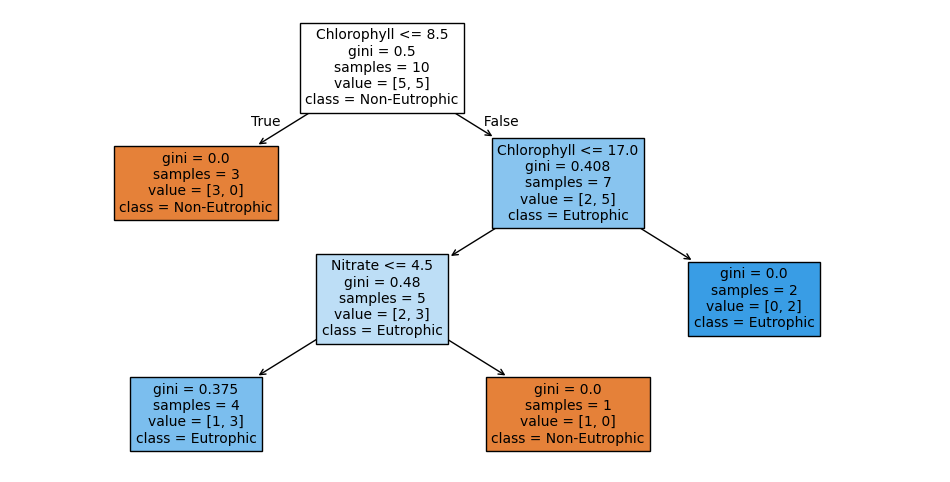

In [13]:
## Import some library needed to use 
from sklearn.tree import plot_tree ## we can also use tree.plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6)) # figure size 

## visualize tree
plot_tree( decision_tree = eutrophic_decision_tree , max_depth = 3 , 
           feature_names = ['Chlorophyll' , 'Nitrate'] , 
           class_names = ['Non-Eutrophic' , 'Eutrophic'] , 
           filled = True , fontsize = 10) 
            ## max_depth , feature_names , class_names

plt.show()

## Step 6: Make a Prediction (Decision Tree)

In [14]:
# (6.1) Create a water sample
## original
new_sample = pd.DataFrame( {"Chlorophyll": [15] , "Nitrate": [4.0]} )

## self-made
water_sample = pd.DataFrame( {"Chlorophyll" : [18,5,5] , 
                              "Nitrate" : [6,6,1.5]} ) # C = 8.5 , N = 4.5 from tree

print(new_sample)
print(water_sample)

   Chlorophyll  Nitrate
0           15      4.0
   Chlorophyll  Nitrate
0           18      6.0
1            5      6.0
2            5      1.5


In [15]:
# (6.2) Predict the class of the new sample
eutrophic_prediction = eutrophic_decision_tree.predict(water_sample) # 0 = Non-Eutrophic , 1 = Eutrophic
print(eutrophic_prediction) # list 

[1 0 0]


In [16]:
for pos in range(len(eutrophic_prediction)) : 
    print("Prediction from Decision Tree : Row " , pos , "is " , ("Eutrophic" if eutrophic_prediction[pos] == 1 else "Non-Eutrophic"))
    
    ## so most importance feature is "Chrolophyll" (Classified by this feature than Nitrate) ## use both but "Chlorophyll"

Prediction from Decision Tree : Row  0 is  Eutrophic
Prediction from Decision Tree : Row  1 is  Non-Eutrophic
Prediction from Decision Tree : Row  2 is  Non-Eutrophic


In [17]:
## check most importance feature using .feature_importance
eutrophic_importnace_arr = eutrophic_decision_tree.feature_importances_ # returning np array of proportion importance [total = 1]
    ## calculated by decreasing "Gini" then weighted

## shown data with Series
importance_series = pd.Series( eutrophic_importnace_arr , index = ["Chlorophyll","Nitrate"]) # label with list
print(importance_series)

Chlorophyll    0.742857
Nitrate        0.257143
dtype: float64


Note : Scikit-Learn User Guide of `export_text`
[Read Here](https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_text.html)

In [18]:
## export decision rule into text using 
from sklearn.tree import export_text
print(export_text(eutrophic_decision_tree , feature_names = ["Chlorophyll","Nitrate"] , class_names = ["Non-Eutrophic" , "Eutrophic"])) 
## Don't forget attribuites feature_names , class_names

|--- Chlorophyll <= 8.50
|   |--- class: Non-Eutrophic
|--- Chlorophyll >  8.50
|   |--- Chlorophyll <= 17.00
|   |   |--- Nitrate <= 4.50
|   |   |   |--- class: Eutrophic
|   |   |--- Nitrate >  4.50
|   |   |   |--- class: Non-Eutrophic
|   |--- Chlorophyll >  17.00
|   |   |--- class: Eutrophic



## Step 7: Train a Gaussian Naive Bayes Model 

In [19]:
from sklearn.naive_bayes import GaussianNB #import library sklearn

# (7.1) Create a Gaussian Naive Bayes classifier
# CategoricalNB for Categorical features
nb_classifier = GaussianNB()

In [20]:
# (7.2) Train the Naive Bayes model
nb_classifier.fit(X, y)

GaussianNB()

## Step 8: Make a Prediction (Naive Bayes)

In [21]:
# (8.1) Predict the class of the new sample
nb_prediction = nb_classifier.predict(new_sample) # given ndarray out

# Display the predicted class
print("Prediction from Decision Tree is " , ("Eutrophic" if nb_prediction[0] == 1 else "Non-Eutrophic"))

Prediction from Decision Tree is  Eutrophic


In [ ]:
# (8.2) Get the probability for each class
print("New Sample Probability")
print(nb_classifier.predict_proba(new_sample))
print("-----------------------") 
print("Water Sample Probability\n")
print(nb_classifier.predict_proba(water_sample)) 

New Sample Probability
[[0.11953624 0.88046376]]
-----------------------
Water Sample Probability

[[0.05591159 0.94408841]
 [0.86168138 0.13831862]
 [0.99717226 0.00282774]]


## Special Part : Decision Boundary Visualization

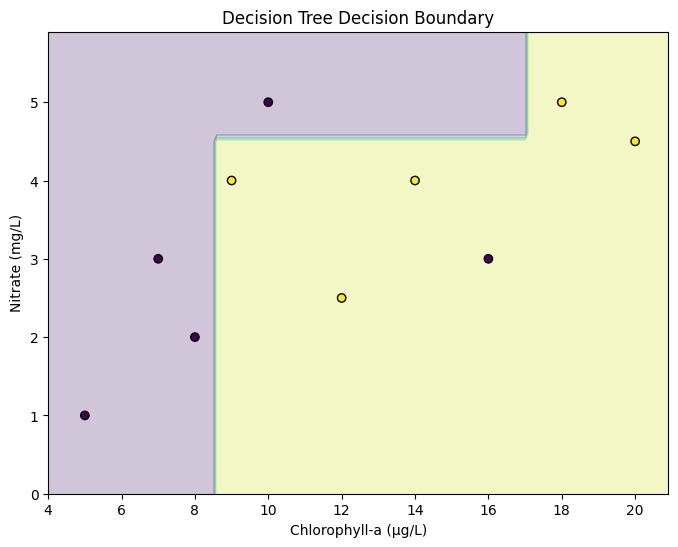

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Create a grid of values
x_min, x_max = X["Chlorophyll"].min() - 1, X["Chlorophyll"].max() + 1
y_min, y_max = X["Nitrate"].min() - 1, X["Nitrate"].max() + 1
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1) 
    )

# Predict the class for every point in the grid
grid = pd.DataFrame({
 "Chlorophyll": xx.ravel(),
 "Nitrate": yy.ravel()
})

# Predict the class for every point in the grid
Z = eutrophic_decision_tree.predict(grid)
Z = Z.reshape(xx.shape)

# Plot the decision regions
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25)

# Plot the original observations
plt.scatter(
 X["Chlorophyll"],
 X["Nitrate"],
 c=y,
 edgecolor="black" )

plt.xlabel("Chlorophyll-a (µg/L)")
plt.ylabel("Nitrate (mg/L)")
plt.title("Decision Tree Decision Boundary")

plt.show()

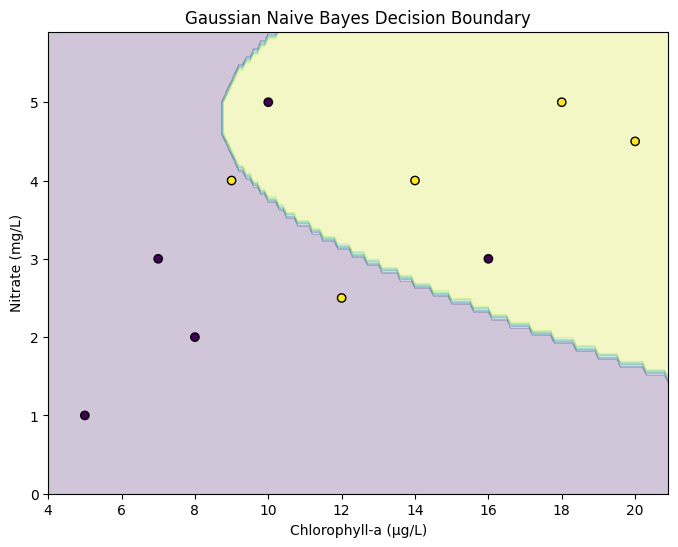

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB # Added for self-containment

# Create and train the Gaussian Naive Bayes classifier within this cell for robustness
nb = GaussianNB()
nb.fit(X, y)

# Create a grid of values
x_min, x_max = X["Chlorophyll"].min() - 1, X["Chlorophyll"].max() + 1
y_min, y_max = X["Nitrate"].min() - 1, X["Nitrate"].max() + 1
xx, yy = np.meshgrid(
 np.arange(x_min, x_max, 0.1),
 np.arange(y_min, y_max, 0.1) )

# Create grid data
grid = pd.DataFrame({
 "Chlorophyll": xx.ravel(),
 "Nitrate": yy.ravel()
})

# Predict the class for every point in the grid
Z = nb.predict(grid)
Z = Z.reshape(xx.shape)

# Plot the decision regions
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25)

# Plot the original observations
plt.scatter(
 X["Chlorophyll"],
 X["Nitrate"],
 c=y,
 edgecolor="black" )

plt.xlabel("Chlorophyll-a (µg/L)")
plt.ylabel("Nitrate (mg/L)")
plt.title("Gaussian Naive Bayes Decision Boundary")
plt.show()